<a href="https://colab.research.google.com/github/madhumitha006/Madhumitha-Codeboosters-internship-2026/blob/main/day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("student_performance.csv")

print("="*50)
print("STUDENT PERFORMANCE ANALYSIS")
print("="*50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistics:")
print(df.describe())

STUDENT PERFORMANCE ANALYSIS

Shape:
(30, 13)

Columns:
Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')

First 5 Rows:
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3  

In [2]:
import sqlite3

conn = sqlite3.connect("student.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


In [3]:
query1 = """
SELECT department,
AVG(programming_score) AS avg_programming
FROM students
GROUP BY department
ORDER BY avg_programming DESC;
"""

print(pd.read_sql_query(query1, conn))

         department  avg_programming
0  Computer Science        89.230769
1       Electronics        61.500000
2        Mechanical        49.333333
3             Civil        40.600000


In [4]:
query2 = """
SELECT gender,
AVG(programming_score) AS avg_score
FROM students
GROUP BY gender;
"""

print(pd.read_sql_query(query2, conn))

   gender  avg_score
0  Female       70.2
1    Male       65.0


In [5]:
query3 = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department;
"""

print(pd.read_sql_query(query3, conn))

         department  avg_attendance
0             Civil       74.600000
1  Computer Science       90.692308
2       Electronics       80.333333
3        Mechanical       83.500000


In [6]:
query4 = """
SELECT name,
department,
programming_score
FROM students
ORDER BY programming_score DESC
LIMIT 5;
"""

print(pd.read_sql_query(query4, conn))

             name        department  programming_score
0      Ananya Das  Computer Science                 97
1     Tanvi Mehta  Computer Science                 96
2      Arjun Nair  Computer Science                 95
3  Akanksha Yadav  Computer Science                 94
4     Divya Singh  Computer Science                 93


In [7]:
query5 = """
SELECT name,
department,
attendance_percentage
FROM students
WHERE attendance_percentage > 90;
"""

print(pd.read_sql_query(query5, conn))

             name        department  attendance_percentage
0    Aarav Sharma  Computer Science                     92
1     Sneha Reddy        Mechanical                     95
2     Divya Singh  Computer Science                     96
3      Ananya Das  Computer Science                     98
4   Kavya Nambiar        Mechanical                     91
5    Ritu Agarwal       Electronics                     93
6  Swati Kulkarni  Computer Science                     94
7     Tanvi Mehta  Computer Science                     97
8       Amit Bose  Computer Science                     91
9  Akanksha Yadav  Computer Science                     95


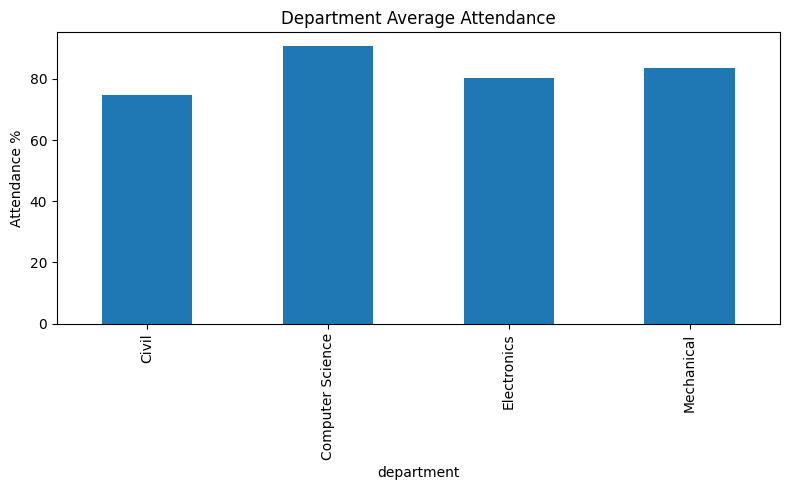

In [8]:
import matplotlib.pyplot as plt

dept_att = df.groupby("department")[
    "attendance_percentage"
].mean()

plt.figure(figsize=(8,5))
dept_att.plot(kind="bar")

plt.title("Department Average Attendance")
plt.ylabel("Attendance %")
plt.tight_layout()
plt.show()

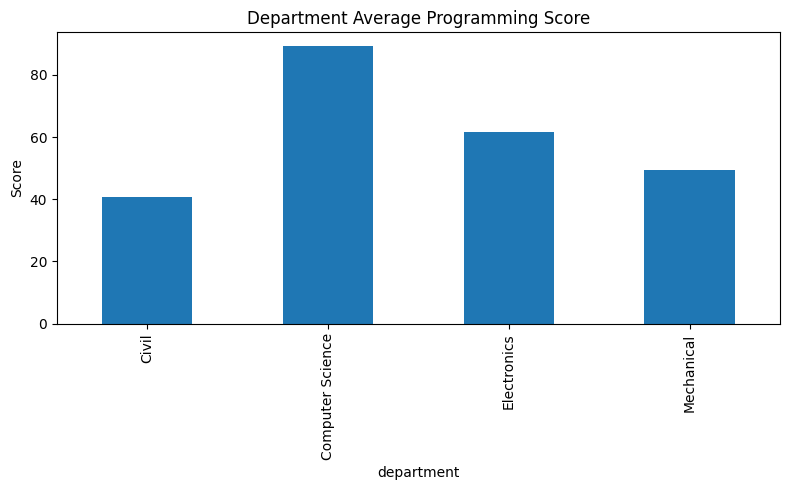

In [9]:
dept_prog = df.groupby("department")[
    "programming_score"
].mean()

plt.figure(figsize=(8,5))
dept_prog.plot(kind="bar")

plt.title("Department Average Programming Score")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

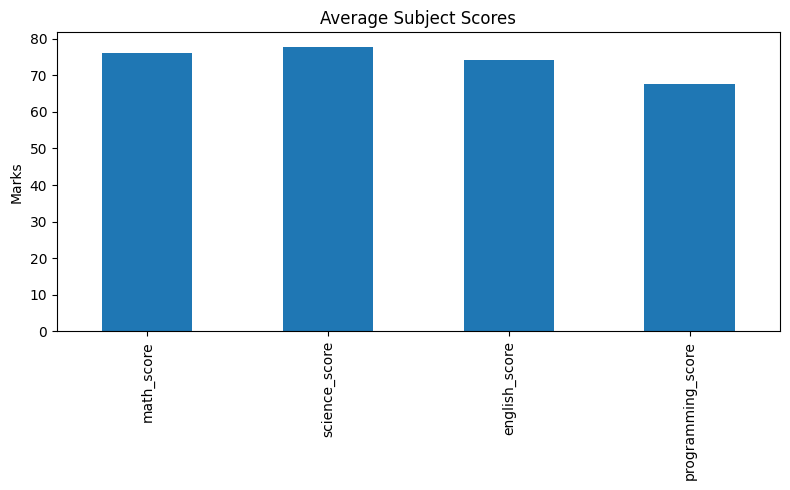

In [10]:
subject_scores = df[
    ["math_score",
     "science_score",
     "english_score",
     "programming_score"]
].mean()

plt.figure(figsize=(8,5))
subject_scores.plot(kind="bar")

plt.title("Average Subject Scores")
plt.ylabel("Marks")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [12]:
le_gender = LabelEncoder()
le_dept = LabelEncoder()
le_city = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["department"] = le_dept.fit_transform(df["department"])
df["city"] = le_city.fit_transform(df["city"])

In [13]:
X = df[
    [
        "age",
        "gender",
        "department",
        "semester",
        "math_score",
        "science_score",
        "english_score",
        "attendance_percentage",
        "city",
        "admission_year"
    ]
]

y = df["programming_score"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
y_pred = rf.predict(X_test)

In [17]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 10.05


In [18]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head())

    Actual  Predicted
27      39      47.46
15      69      88.85
23      53      73.50
17      92      92.90
8       45      53.28


In [19]:
X = df[
    [
        'age',
        'semester',
        'math_score',
        'science_score',
        'english_score',
        'attendance_percentage',
        'admission_year'
    ]
]

y = df['programming_score']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 11.756666666666668


In [21]:
df['gender'] = df['gender'].replace({
    'Male': 0,
    'Female': 1
})

In [22]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head())

    Actual  Predicted
27      39      56.30
15      69      91.47
23      53      73.01
17      92      93.34
8       45      52.53


In [ ]:
qxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx